In [ ]:
<h1> Лабораторная работа 5 </h1>

<h2>Технологии программирования </h2>

<h3> Выполнил: </h3> 
<h4> Толстых Максим Алексеевич </h4>

<h3> Группа: </h3>
<h4> НММбд-02-22 </h4>

<h2> Цель работы </h2>

Изучить вероятности экспозиции совместно с
вероятностью блокировки на основе модели антенн.

<h2> Ход работы </h2>

Для выполнения задания скопировали код предыдущей лабораторной работы.

In [1]:
#импортировали 
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import math
from numpy.linalg import norm
from numpy import arccos, dot, pi, cross

In [2]:
guard_size = 10
poisson_lam_block = 0.3
radius_block = 0.5
distance_Tx_Rx = 3
list_point = np.array

In [3]:
# Рисуем круг
def plot_circle(x, y, r):
    angles = np.linspace(0, 2 * np.pi, 50)
    x_cir = x + r * np.cos(angles)
    y_cir = y + r * np.sin(angles)
    plt.plot(x_cir, y_cir, 'red')

In [4]:
# Инициализация Пуассоновского точечного процесса
def poisson_point_process(lambda0,area_size):
    Number_block = np.random.poisson(lambda0 * area_size**2) 
    x = np.random.uniform (0, area_size, size=Number_block) 
    y = np.random.uniform (0, area_size, size=Number_block) 
    return x,y

In [5]:
# Функция для прямоугольника вокруг линии прямой видимости
def paint_rectangle(x_point_1, y_point_1, x_point_2, y_point_2, angle):
    difference_angle = 2 * np.pi - angle
    reverse_angle = np.pi / 2 - difference_angle
    opposite_angle = reverse_angle + np.pi
    x_rectang_A = x_point_1 + radius_block * np.cos(opposite_angle)
    y_rectang_A = y_point_1 + radius_block * np.sin(opposite_angle)
    x_rectang_B = x_point_1 + radius_block * np.cos(reverse_angle) 
    y_rectang_B = y_point_1 + radius_block * np.sin(reverse_angle) 
    x_rectang_C = x_point_2 + radius_block * np.cos(reverse_angle) 
    y_rectang_C = y_point_2 + radius_block * np.sin(reverse_angle)
    x_rectang_D = x_point_2 + radius_block * np.cos(opposite_angle)
    y_rectang_D = y_point_2 + radius_block * np.sin(opposite_angle)
    return x_rectang_A, y_rectang_A, x_rectang_B, y_rectang_B, x_rectang_C, y_rectang_C, x_rectang_D, y_rectang_D

In [6]:
def check_distance(A, B, C):
    CA = (C - A) / norm(C - A)
    BA = (B - A) / norm(B - A)
    CB = (C - B) / norm(C - B)
    AB = (A - B) / norm(A - B)
    if arccos(dot(CA, BA)) > 1:
        return norm(C - A)
    if arccos(dot(CB, AB)) > 1:
        return norm(C - B)
    return norm(cross(A - B, A - C)) / norm(B - A)

In [7]:
def crossing():
    circle_point = [];
    point_1 = [];
    point_2 = [];
    point_1.extend([x1, y1])
    point_2.extend([x2, y2])
    for i in range(len(x)):
        circle_point. append([x[i], y[i]])
    for i in range(len(x)):
        if (np.round(check_distance(list_point(point_1), list_point(point_2), list_point(circle_point[i])), 1) <= radius_block): 
            return True

На двух точках, между которыми
производится проверка прямой видимости, сформировали диаграмму
направленности, задающуюся вектором направления и углом.
Алгоритм строился из предположения, что если для обеих из рассматриваемых точек вторая точка
лежит внутри сектора, описанного вектором и углом и линия прямой
видимости между ними не заблокирована, то точки находятся в области
видимости друг друга.
Направление вектора диаграммы задали случайно
равномерно распределенной величиной от 0 до 2Pi, а угол - константа.
Определили находятся ли рассматриваемые точки в области
видимости друг друга.

In [16]:
dist_alpha = 4
alpha = np.pi/2

In [17]:
def plot_alpha(x1,y1, rand_angl, draw=True):
    x2 = x1 + dist_alpha * np.cos(rand_angl)
    y2 = y1 + dist_alpha * np.sin(rand_angl)
    x3 = x1 + dist_alpha * np.cos(rand_angl + alpha)
    y3 = y1 + dist_alpha * np.sin(rand_angl + alpha)
    if draw:
        plt.plot([x1,x2], [y1,y2], "--g", )
        plt.plot([x1,x3], [y1,y3], "--g", )
        return x2,y2,x3,y3
    else:
        return x2,y2,x3,y3

In [18]:
def polar_coords(x, y):
    r = np.sqrt(x**2 + y**2)
    p = np.arctan2(y, x)
    return(r, p)

In [19]:
# Проверка видимости
def check_visibility():
    r1 = polar_coords(a1x2-x1, a1y2-y1)[1] if polar_coords(a1x2-x1, a1y2-y1)[1] >= 0 else polar_coords(a1x2-x1, a1y2-y1)[1] + np.pi*2
    g1 = polar_coords(x2-x1, y2-y1)[1] if polar_coords(x2-x1, y2-y1)[1] >= 0 else polar_coords(x2-x1, y2-y1)[1] + np.pi*2
    b1 = polar_coords(a1x3-x1, a1y3-y1)[1] if polar_coords(a1x3-x1, a1y3-y1)[1] >= 0 else polar_coords(a1x3-x1, a1y3-y1)[1] + np.pi*2
    
    r2 = polar_coords(a2x2-x2, a2y2-y2)[1] if polar_coords(a2x2-x2, a2y2-y2)[1] >= 0 else polar_coords(a2x2-x2, a2y2-y2)[1] + np.pi*2
    g2 = polar_coords(x1-x2, y1-y2)[1] if polar_coords(x1-x2, y1-y2)[1] >= 0 else polar_coords(x1-x2, y1-y2)[1] + np.pi*2
    b2 = polar_coords(a2x3-x2, a2y3-y2)[1] if polar_coords(a2x3-x2, a2y3-y2)[1] >= 0 else polar_coords(a2x3-x2, a2y3-y2)[1] + np.pi*2
    
    if g1 > r1 and g1 < b1 and g2 > r2 and g2 < b2: 
        return True
    else:
        return False

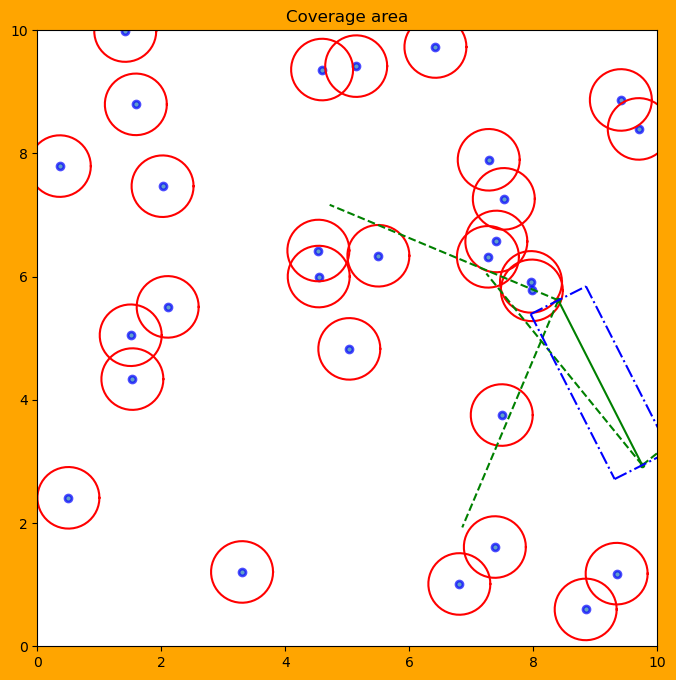

In [31]:
x, y = poisson_point_process(poisson_lam_block, guard_size)

x1 = np.random.uniform (0, guard_size) 
y1 = np.random.uniform (0, guard_size) 

angle = np.random.uniform (0,2 * np.pi)

x2 = x1 + distance_Tx_Rx * np.cos(angle) 
y2= y1 + distance_Tx_Rx * np.sin(angle)

x_rectang_A, y_rectang_A, x_rectang_B, y_rectang_B, x_rectang_C, y_rectang_C, x_rectang_D, y_rectang_D = paint_rectangle(x1, y1, x2, y2, angle)

plt.figure(dpi=100, figsize=(8,8),facecolor='orange')
plt.title('Coverage area')
plt.plot(x,y,'.',alpha=0.7, label="first", lw=5, mec='b', mew=2, ms=10)

for i in range(len(x)):
    plot_circle(x[i], y[i], radius_block)
plt.plot([x1,x2], [y1,y2], '.-g')

a1x2, a1y2, a1x3, a1y3 = plot_alpha(x1,y1,np.random.uniform(0, 2*np.pi))
a2x2, a2y2, a2x3, a2y3 = plot_alpha(x2,y2,np.random.uniform(0, 2*np.pi))

plt.plot([x_rectang_A,x_rectang_B], [y_rectang_A,y_rectang_B], '-.b')
plt.plot([x_rectang_A,x_rectang_D], [y_rectang_A,y_rectang_D], '-.b')
plt.plot([x_rectang_B,x_rectang_C], [y_rectang_B,y_rectang_C], '-.b')
plt.plot([x_rectang_D,x_rectang_C], [y_rectang_D,y_rectang_C], '-.b')
plt.xlim(0, guard_size) 
plt.ylim(0, guard_size)
plt. show()

In [32]:
if (crossing()):
    print('Los blocked')
else:
    print ('Los is not blocked')


Los blocked


In [33]:
if check_visibility():
    print("Objects are visible")
else:
    print("Objects are NOT visible")

Objects are NOT visible


На основе 1000 реализаций определили вероятность нахождения
точек в области видимости друг друга. Полученный результат сравнили с
результатами математической модели.

In [34]:
#Имитационное моделирование
N = 1000
summa = 0

for i in range(N):
    x, y = poisson_point_process(poisson_lam_block,guard_size)
    x1 = np.random.uniform (0, guard_size)
    y1 = np.random.uniform (0, guard_size)
    angle = np.random.uniform (0,2 * np.pi)
    x2 = x1 + distance_Tx_Rx * np.cos(angle)
    y2 = y1 + distance_Tx_Rx * np.sin(angle)
    if (crossing()) and (check_visibility()):
        summa += 1
print("Вероятность блокировки: ", summa/N)

Вероятность блокировки:  0.02


In [36]:
# Вероятность блокировки по аналитической формуле
s = 2 * radius_block * distance_Tx_Rx 
lamb = poisson_lam_block * s
probability = 1 - np.exp(-lamb)
probability = probability * (alpha ** 2) / (4 * np.pi ** 2)
print("Вероятность блокировки по аналитической формуле:", probability)

Вероятность блокировки по аналитической формуле: 0.03708939626621255


<h2> Вывод </h2>

В ходе выполнения лабораторной работы были изучены вероятности экспозиции совместно с
вероятностью блокировки на основе модели антенн.